**Correlation Analysis of Inflation, USD/TRY Exchange Rate, GDP Per Capita, and Unemployment in Turkey During and After COVID-19**

**Introduction**

An emerging market describes the Turkish economy. It went through times of large macroeconomic change in the past. The USD/TRY exchange rate, GDP per capita as well as unemployment show the economic health and stability. Investors next to analysts watch these indicators. The indicators give information about the economy's performance and possible dangers. In early 2020 the COVID-19 pandemic began. It was an economic shock to the globe and this shock changed macroeconomic relationships. Like other nations, Turkıye had economic problems because of the pandemic, but Turkiye having economic problems before the pandemic.The pandemic made the economic problems deeper. It disrupted supply chains, lowered demand in addition to made the future uncertain and these returned as unempoyment. Because of this situation, this researc aim to analyzes the correlations between inflation, the USD/TRY exchange rate, GDP per capita along with unemployment.

**2. Overview of Macroeconomic Trends in Turkey**



**2.1. Pre-COVID-19 Period (Up to Early 2020)**

Up to early 2020 the period before COVID-19, Turkey had difficult macroeconomic situations. The inflation rate in Turkey was about increase at the end of 2018 . In addition to this USD/TRY exchange rate had a big depreciation. The Turkish Lira became considerably weaker, mainly after the financial problems of 2018.But in a year after this inflation rate in Turkiye decresead.Voyvoda & Yelda( 2020) stated that in the end of 2019 the inflation rate in Turkiye almost 11 % .After this decrease Turkiye's inflation rates started to accelarate Turkish economy were facing problems before pandemic and pandemic ignited more problems, these problems were increasing inflation and depreciating foreign exchange rates. For instance USDTRY levels significantly depreciated after 2018 and inflation rate peak.

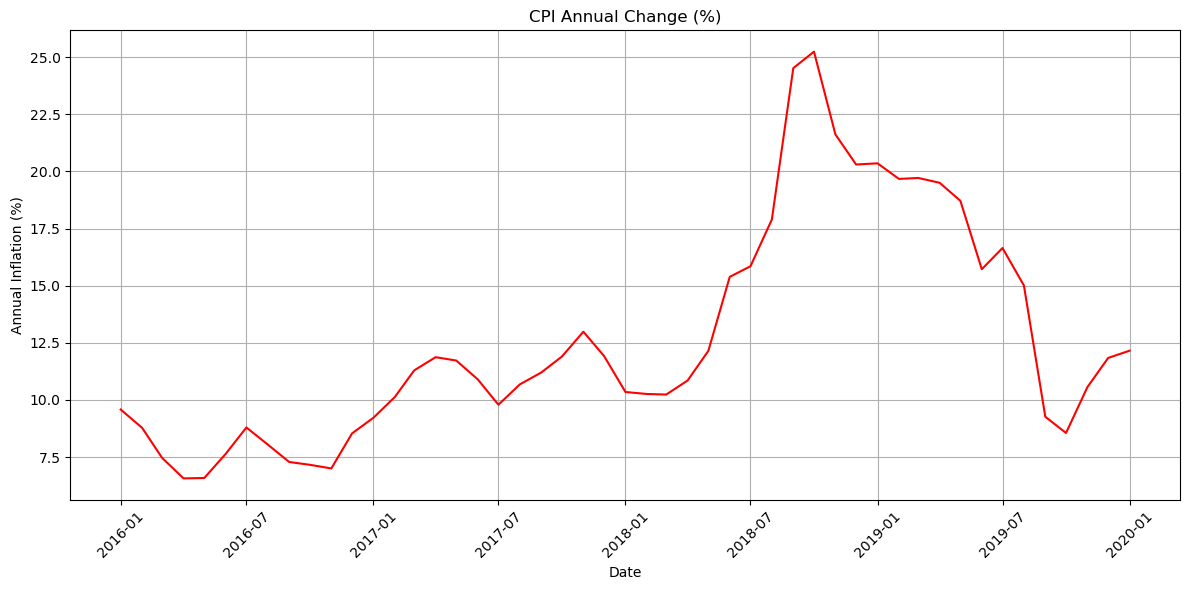

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI
import matplotlib.dates as mdates

# API key
api_key = 'YOUR_EVDS_API_KEY'

# Start and end dates
start_date = "01-01-2015"
end_date = "01-01-2020"
cpi_code = 'TP.FG.J0'

data = evds.get_data([cpi_code], startdate=start_date, enddate=end_date)

data["Tarih"] = pd.to_datetime(data["Tarih"])
data = data.set_index("Tarih")

# Draw the Graph
cpi_column = cpi_code.replace('.', '_')
cpi_column in data.columns
data["CPI_Annual"] = data[cpi_column].pct_change(12) * 100
plt.figure(figsize=(12,6))
plt.plot(data.index, data["CPI_Annual"], color='red')
plt.title("CPI Annual Change (%)")
plt.xlabel("Date")
plt.ylabel("Annual Inflation (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 By the end of 2019, the exchange rate had depreciated by around 22%.

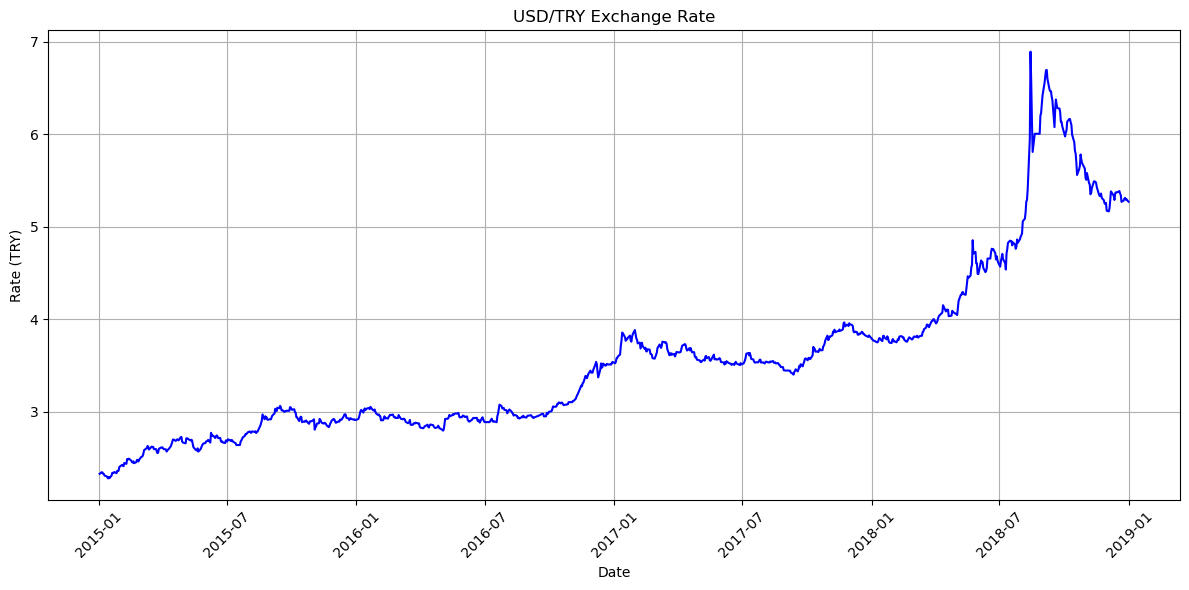

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI
import matplotlib.dates as mdates

api_key = 'YOUR_EVDS_API_KEY'

usd_try_code = 'TP.DK.USD.S.YTL'
usd_try_title = 'USD/TRY Exchange Rate'

start_date = "01-01-2015"
end_date = "01-01-2019"

evds = evdsAPI(api_key)
data = evds.get_data([usd_try_code], startdate=start_date, enddate=end_date)

# Convert DATE format
data["Tarih"] = pd.to_datetime(data["Tarih"], dayfirst=True)
data = data.set_index("Tarih").dropna()

# Draw graph
usd_try_column = usd_try_code.replace('.', '_')
plt.figure(figsize=(12,6))
plt.plot(data.index, data[usd_try_column], color='blue')
plt.title(usd_try_title)
plt.xlabel("Date")
plt.ylabel("Rate (TRY)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

By the end of 2019, the exchange rate had depreciated by around 22%.

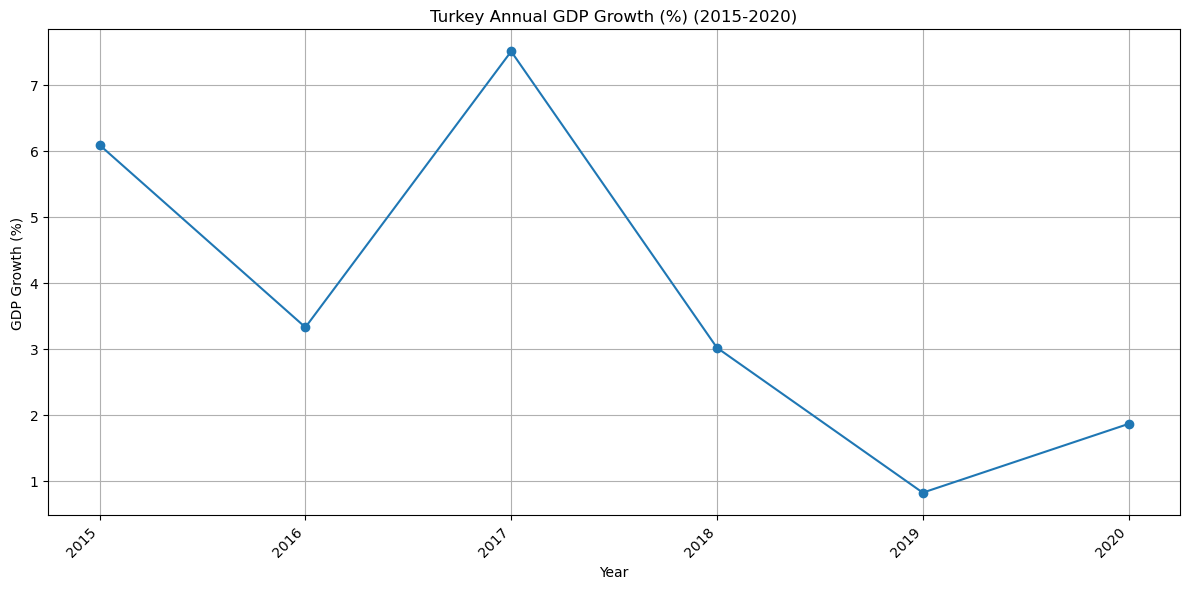

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Hocam in GDP graphs we get data from World Bank
data_row = "Turkiye,\"TUR\",\"GDP growth (annual %)\",\"NY.GDP.MKTP.KD.ZG\",\"\",\"1.15606938539699\",\"5.57142858180484\",\"9.06630555240875\",\"5.45905679838097\",\"2.82352954343837\",\"11.2128150353514\",\"4.73251024393741\",\"6.77799601038116\",\"4.0811456208947\",\"3.2335089729326\",\"5.56669450058789\",\"7.42578832564243\",\"3.26233451840511\",\"5.59447440269336\",\"7.17411268977106\",\"10.4611795563238\",\"3.40666980449156\",\"1.50293301122329\",\"-0.624113570222889\",\"-2.44735042580156\",\"4.85664876652039\",\"3.56322781218346\",\"4.97108077727097\",\"6.71201571206008\",\"4.24133571639945\",\"7.01203111054399\",\"9.48553884246731\",\"2.3207367939484\",\"0.2902440687796\",\"9.26614667149323\",\"0.720279035610048\",\"5.03563493896803\",\"7.65126520301509\",\"-4.66814736394838\",\"7.87826687618991\",\"7.37966447375686\",\"7.57766364407608\",\"2.40415025686937\",\"-3.26316840597104\",\"6.93323970455904\",\"-5.75000655464257\",\"6.44772204681594\",\"5.76320606654714\",\"9.79593638920282\",\"8.99230493626517\",\"6.94798808571993\",\"5.04350793157104\",\"0.815024573007705\",\"-4.82315395301769\",\"8.42710432276191\",\"11.2001105833504\",\"4.78849271108008\",\"8.48581699653026\",\"4.9397151613658\",\"6.08448690443663\",\"3.32308420845746\",\"7.50199748917491\",\"3.0131703931215\",\"0.818514526726673\",\"1.85987303976462\",\"11.4393956926566\",\"5.53342787492781\",\"5.11116818488702\",\"\""
data_series = pd.Series(data_row.split(','))

# Select the GDP growth rates
gdp_growth_str = data_series[5:-1].str.replace('"', '')
gdp_growth = gdp_growth_str.astype(float)

# Create the years
start_year = 1961
years = range(start_year, start_year + len(gdp_growth))

df = pd.DataFrame({'Year': years, 'Growth': gdp_growth})

# We filter the date what we want
start_filter = 2015
end_filter = 2020
filtered_df = df[(df['Year'] >= start_filter) & (df['Year'] <= end_filter)]

# Draw Graph
plt.figure(figsize=(12, 6))
plt.plot(filtered_df['Year'], filtered_df['Growth'], marker='o', linestyle='-')
plt.title(f'Turkey Annual GDP Growth (%) ({start_filter}-{end_filter})')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.grid(True)
plt.xticks(filtered_df['Year'], rotation=45, ha='right') # Show only the filtered years on the x-axis
plt.tight_layout()
plt.show()

In terms of economic growth, the GDP per capita growth rate in 2019 was relatively low, at almost 1%. This modest growth indicated a slowdown in economic activity prior to the pandemic.

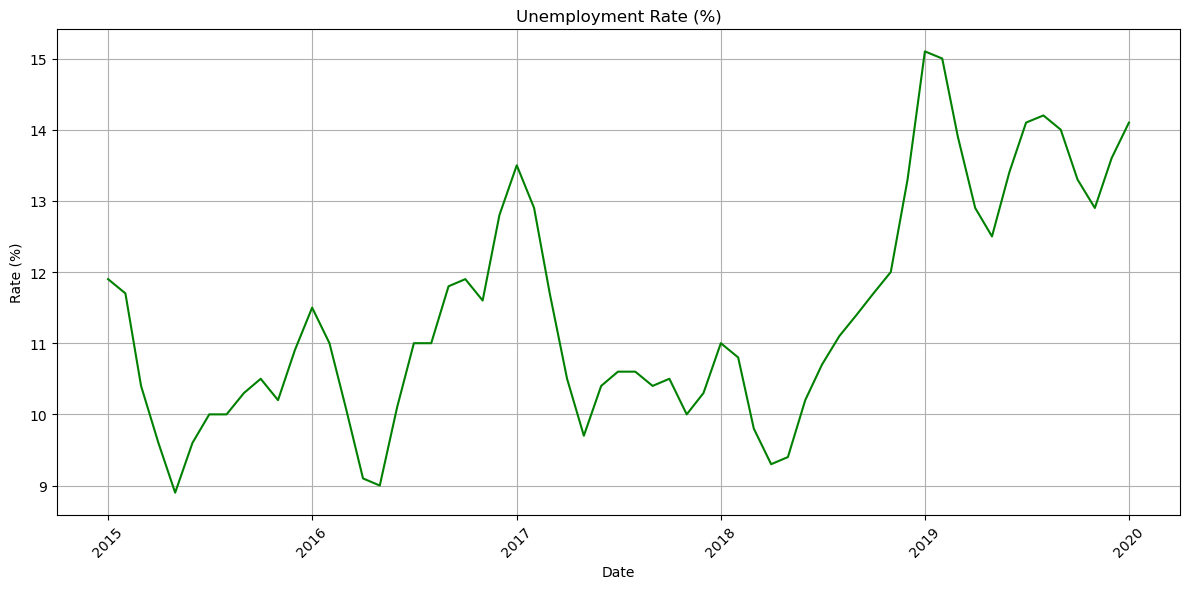

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI

# API key
api_key = 'YOUR_EVDS_API_KEY'

unemployment_code = 'TP.YISGUCU2.G8'
unemployment_title = 'Unemployment Rate (%)'
start_date = "01-01-2015"
end_date = "01-01-2020"

evds = evdsAPI(api_key)

# Get data
data = evds.get_data([unemployment_code], startdate=start_date, enddate=end_date)

# Convert Datw
data["Tarih"] = pd.to_datetime(data["Tarih"], format='mixed', dayfirst=False, errors='coerce')
data = data.set_index("Tarih").dropna()  # Set index and drop NaT values
unemployment_column = unemployment_code.replace('.', '_')

plt.figure(figsize=(12, 6))
plt.plot(data.index, data[unemployment_column], color='green')
plt.title(unemployment_title)
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The growth in unemployment, which has been increasing since 2018, peaked in 2019 and began decreasing afterwards. Problems that already existed prior to the pandemic have paved the way for problems that shall be faced during the pandemic to increase in impact. As per Voyvoda & Yelda( 2020) Turkey's unemployment rate was also high, at 13.6% towards the end of 2019, and even higher, at 16%, in non-agricultural work and 23.9% among the young workforce.

This information as a whole shows a negative macroeconomic environment in Turkey on the eve of the COVID-19 pandemic. Increased unemployment and inflation coupled with a deteriorating currency and sluggish economic growth on a weak base made the Turkish economy particularly susceptible to such an external shock like the pandemic.

**2.2. During the COVID-19 Pandemic (Early 2020 - Mid 2021)**

With the start of the Covid-19 pandemic, problems began to emerge in the Turkish economy, which was already in a difficult situation. The disruptions in production lines due to the danger of the disease and the decrease in demand that came with the complete closure caused the struggling economy to be dragged into an even more difficult situation. As a result of all these negativities, fluctuating increases in inflation and the depreciation of the Turkish lira were inevitable.

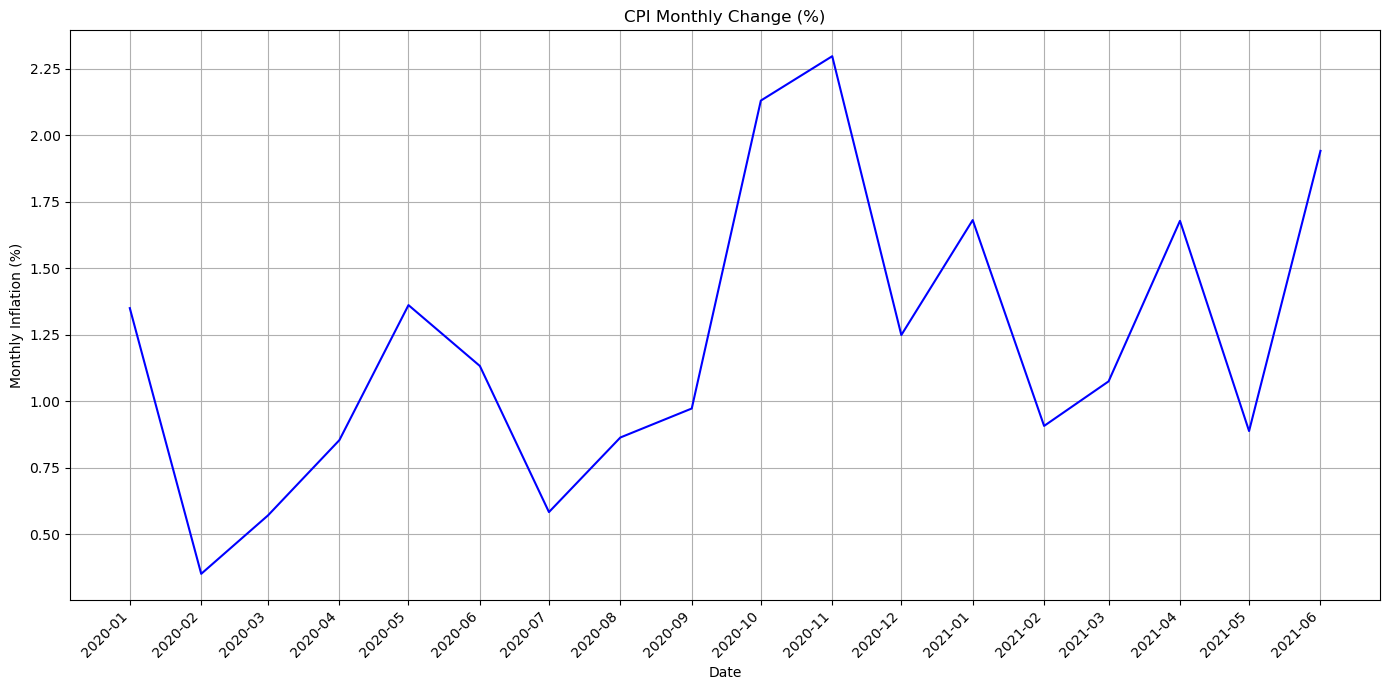

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI
import matplotlib.dates as mdates

api_key = 'YOUR_EVDS_API_KEY'

start_date = "31-12-2019"
end_date = "01-06-2021"
cpi_code = 'TP.FG.J0'

evds = evdsAPI(api_key)

# Get data
data = evds.get_data([cpi_code], startdate=start_date, enddate=end_date)


data["Tarih"] = pd.to_datetime(data["Tarih"])
data = data.set_index("Tarih")

# Draw Graph
cpi_column = cpi_code.replace('.', '_')
data["CPI_Monthly"] = data[cpi_column].pct_change() * 100
plt.figure(figsize=(14, 7))
plt.plot(data.index, data["CPI_Monthly"], color='blue')
plt.title("CPI Monthly Change (%)")
plt.xlabel("Date")
plt.ylabel("Monthly Inflation (%)")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

In addition to the fluctuations caused by Covid-19, the monetary and credit expansions aimed at supporting producers and consumers have also begun to make rising inflation a deeper problem. World bank(2021) reported that the low-income families' food basket almost increased 14%

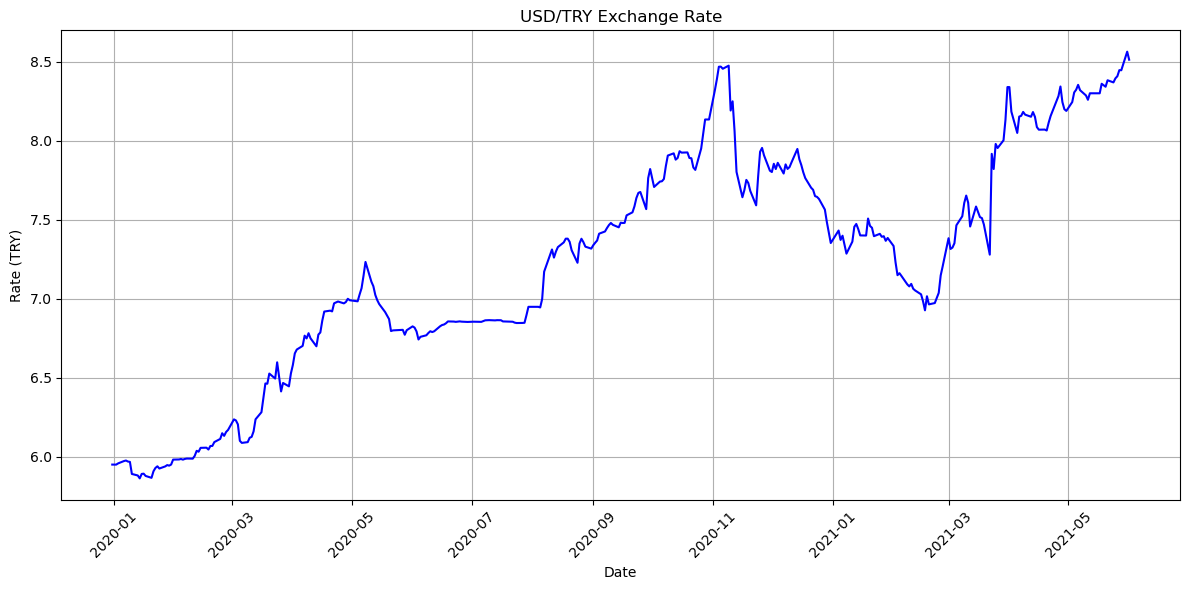

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI

api_key = 'YOUR_EVDS_API_KEY'

usd_try_code = 'TP.DK.USD.S.YTL'
usd_try_title = 'USD/TRY Exchange Rate'
start_date = "31-12-2019"
end_date = "01-06-2021"

evds = evdsAPI(api_key)

data = evds.get_data([usd_try_code], startdate=start_date, enddate=end_date)

# Convert Date format
data["Tarih"] = pd.to_datetime(data["Tarih"], dayfirst=True)
data = data.set_index("Tarih").dropna()

# Draw Graph
usd_try_column = usd_try_code.replace('.', '_')
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[usd_try_column], color='blue')
plt.title(usd_try_title)
plt.xlabel("Date")
plt.ylabel("Rate (TRY)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Along with all the problems experienced, global uncertainties continued to put even more pressure on the Turkish economy, which was in a difficult situation. As a result of this pressure and the completely fragile economy, fluctuations in exchange rates had also begun. During this process, the Turkish lira was losing blood at a high rate against the dollar. During this process, the Turkish lira lost almost a third of its value against the dollar and addition to this the dollar exchange rate, which was around 5.5 lira at the end of 2019, reached around 7 lira towards the middle of 2020.

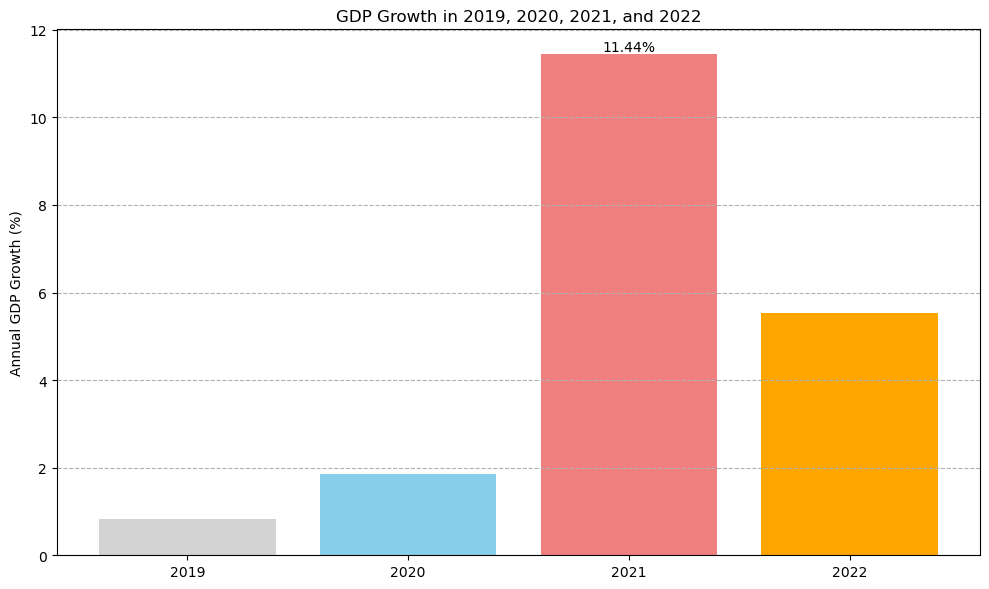

In [151]:
import matplotlib.pyplot as plt

# Data from the World Bank
data_row = "Turkiye,\"TUR\",\"GDP growth (annual %)\",\"NY.GDP.MKTP.KD.ZG\",\"\",\"1.15606938539699\",\"5.57142858180484\",\"9.06630555240875\",\"5.45905679838097\",\"2.82352954343837\",\"11.2128150353514\",\"4.73251024393741\",\"6.77799601038116\",\"4.0811456208947\",\"3.2335089729326\",\"5.56669450058789\",\"7.42578832564243\",\"3.26233451840511\",\"5.59447440269336\",\"7.17411268977106\",\"10.4611795563238\",\"3.40666980449156\",\"1.50293301122329\",\"-0.624113570222889\",\"-2.44735042580156\",\"4.85664876652039\",\"3.56322781218346\",\"4.97108077727097\",\"6.71201571206008\",\"4.24133571639945\",\"7.01203111054399\",\"9.48553884246731\",\"2.3207367939484\",\"0.2902440687796\",\"9.26614667149323\",\"0.720279035610048\",\"5.03563493896803\",\"7.65126520301509\",\"-4.66814736394838\",\"7.87826687618991\",\"7.37966447375686\",\"7.57766364407608\",\"2.40415025686937\",\"-3.26316840597104\",\"6.93323970455904\",\"-5.75000655464257\",\"6.44772204681594\",\"5.76320606654714\",\"9.79593638920282\",\"8.99230493626517\",\"6.94798808571993\",\"5.04350793157104\",\"0.815024573007705\",\"-4.82315395301769\",\"8.42710432276191\",\"11.2001105833504\",\"4.78849271108008\",\"8.48581699653026\",\"4.9397151613658\",\"6.08448690443663\",\"3.32308420845746\",\"7.50199748917491\",\"3.0131703931215\",\"0.818514526726673\",\"1.85987303976462\",\"11.4393956926566\",\"5.53342787492781\",\"5.11116818488702\",\"\""
data_list = data_row.split(',')
gdp_growth_rates = [float(rate.replace('"', '')) for rate in data_list[5:-1]]
start_year = 1961
years = list(range(start_year, start_year + len(gdp_growth_rates)))
selected_years = [2019, 2020, 2021, 2022]
selected_growth_rates = [gdp_growth_rates[years.index(year)] for year in selected_years if year in years]
colors = ['lightgray', 'skyblue', 'lightcoral', 'orange']
# Draws Graph
plt.figure(figsize=(10, 6))
plt.bar([str(year) for year in selected_years], selected_growth_rates, color=colors)
plt.ylabel('Annual GDP Growth (%)')
plt.title('GDP Growth in 2019, 2020, 2021, and 2022')
plt.grid(axis='y', linestyle='--')
for i, growth in enumerate(selected_growth_rates):
    if selected_years[i] == 2021:
        plt.text(str(selected_years[i]), growth, f'{growth:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

The Turkish economy went into a sudden contraction in GDP with an estimated fall of 26.7% per annum due to the policies introduced to stem the flow of the virus. Various scenarios were also anticipated that varied from a negative impact of GDP by 3% to 16% based on both the strength and length of the pandemic. The economy declined by 9.9% in the second quarter of 2020 with nearly immediate suspension of economic activities. Yet, leading indicators indicated a follow-through recovery, with a sharp rebound seen in the third quarter of 2020.

During the pandemic Turkiye's gdp increasing ratio is depreciated, generally Turkiye's economy is growing 5-6 % but in 2019 and 2020 Turkıye's gdp growth became under the 2%. After the 2020, the wounds of pandemics are healing Turkıye's gdp accelerated and annual gdp increase became more than 10 %. The reason of this increase is mainly, the wheel of economy restarted to turn.

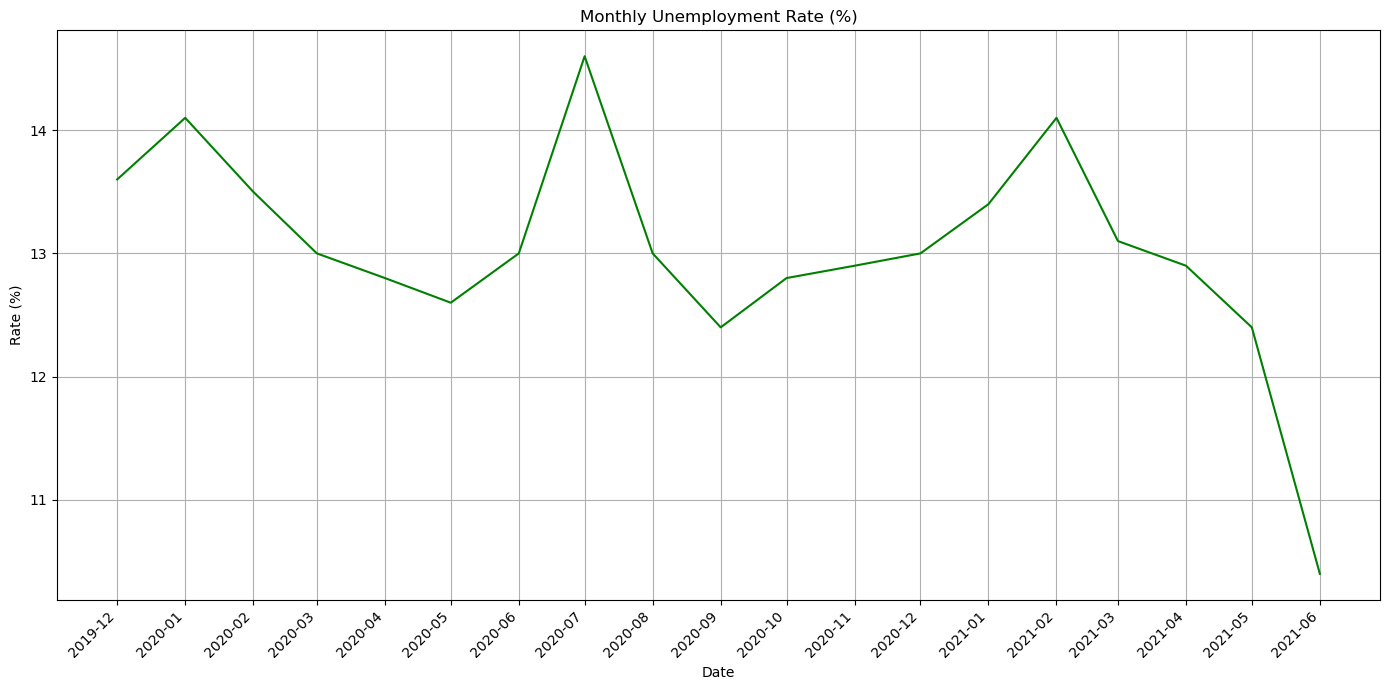

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI
import matplotlib.dates as mdates

api_key = 'YOUR_EVDS_API_KEY'
unemployment_code = 'TP.YISGUCU2.G8'
unemployment_title = 'Monthly Unemployment Rate (%)'
start_date = "31-12-2019"
end_date = "01-06-2021"

evds = evdsAPI(api_key)
data = evds.get_data([unemployment_code], startdate=start_date, enddate=end_date)

# Date Converter
data["Tarih"] = pd.to_datetime(data["Tarih"], format='mixed', dayfirst=False, errors='coerce')
data = data.set_index("Tarih").dropna()

# dRAW GRAPH
unemployment_column = unemployment_code.replace('.', '_')
plt.figure(figsize=(14, 7))
plt.plot(data.index, data[unemployment_column], color='green')
plt.title(unemployment_title)
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

During the pandemic, Turkiye's economy started to shrink because of the pre pandemic problems and the new problems came with pandemic. Baez & Demirgüç (2021) reported that depreciation in global trade and tourism caused almost 3 million people to lose their jobs in Turkiye.

**2.3. Post-COVID-19 Period (Mid 2021 Onwards)**

The Turkish economy had important structural and macroeconomic problems after the COVID-19 pandemic and the recovery efforts that followed. According to the World Bank (2022), inflation pressures stayed. High macro-financial changes plus the lessening value of the Turkish Lira caused the persistent inflation. In May 2024, annual inflation reached a high point of about 75 % because of that. In March 2025, inflation lowered to 38 %, but that number stayed a high number when measured against past numbers. Expectations showed continued price pressures soon. Despite a common lowering in inflation, continuing problems in the services sector continued to stop larger economic stabilization and recovery.

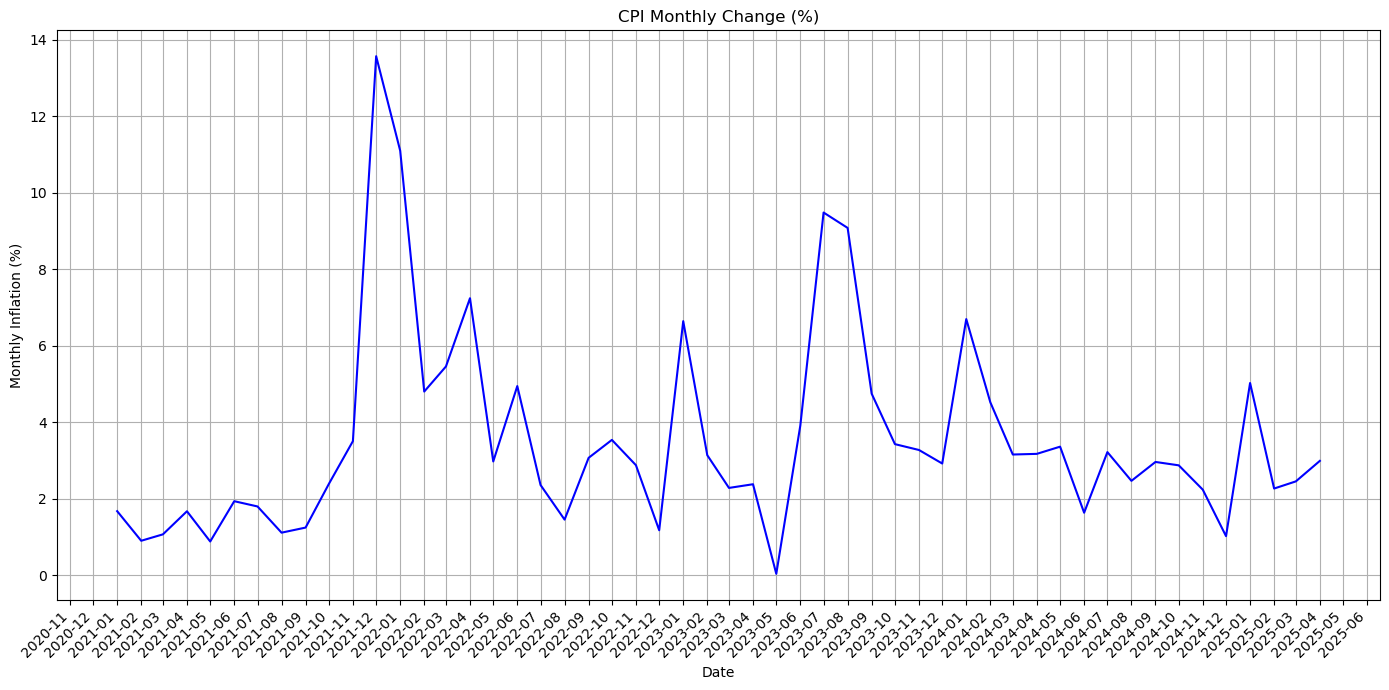

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI
import matplotlib.dates as mdates

api_key = 'YOUR_EVDS_API_KEY'

start_date = "31-12-2020"
end_date = "01-04-2025"
cpi_code = 'TP.FG.J0'

evds = evdsAPI(api_key)
data = evds.get_data([cpi_code], startdate=start_date, enddate=end_date)

data["Tarih"] = pd.to_datetime(data["Tarih"])
data = data.set_index("Tarih")

# Draws Graph
cpi_column = cpi_code.replace('.', '_')
data["CPI_Monthly"] = data[cpi_column].pct_change() * 100
plt.figure(figsize=(14, 7))
plt.plot(data.index, data["CPI_Monthly"], color='blue')
plt.title("CPI Monthly Change (%)")
plt.xlabel("Date")
plt.ylabel("Monthly Inflation (%)")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

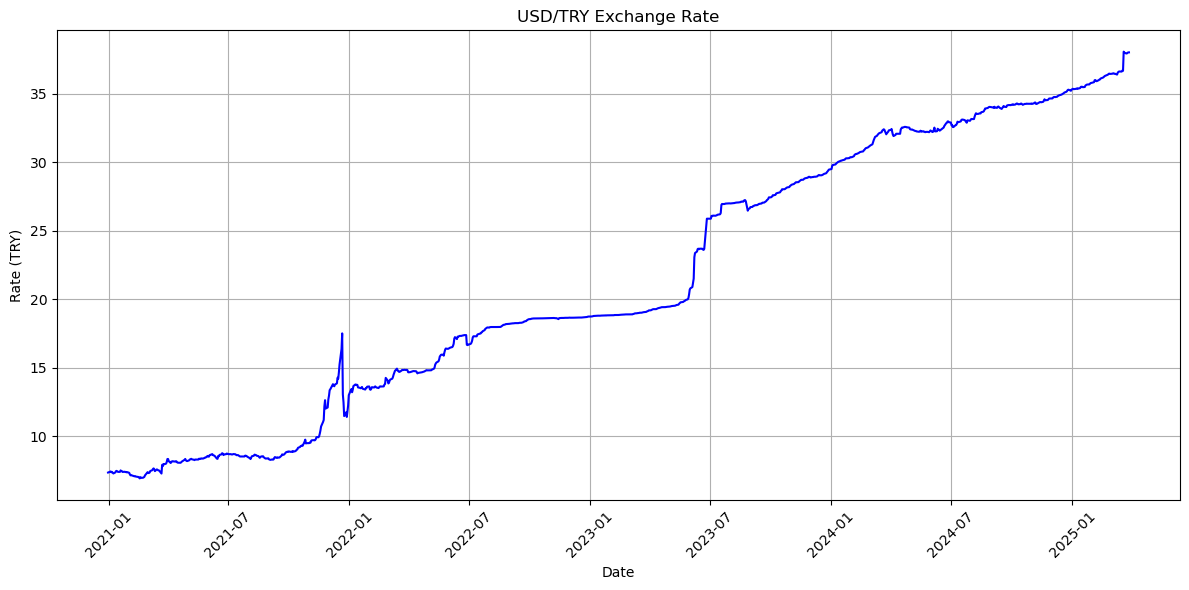

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI

api_key = 'YOUR_EVDS_API_KEY'

usd_try_code = 'TP.DK.USD.S.YTL'
usd_try_title = 'USD/TRY Exchange Rate'
start_date = "31-12-2020"
end_date = "01-04-2025"

evds = evdsAPI(api_key)

# Get data
data = evds.get_data([usd_try_code], startdate=start_date, enddate=end_date)

# Converts Date Format
data["Tarih"] = pd.to_datetime(data["Tarih"], dayfirst=True)
data = data.set_index("Tarih").dropna()

# Draw USD/TRY Graph
usd_try_column = usd_try_code.replace('.', '_')
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[usd_try_column], color='blue')
plt.title(usd_try_title)
plt.xlabel("Date")
plt.ylabel("Rate (TRY)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

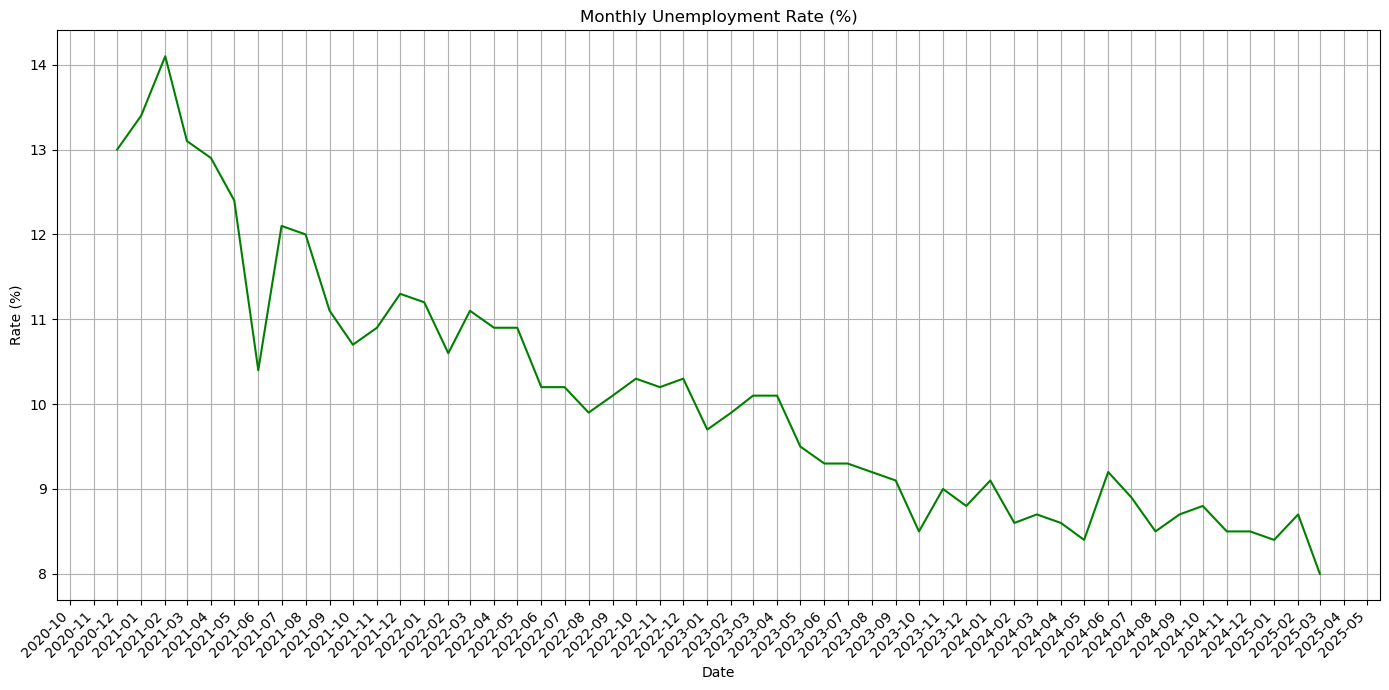

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI
import matplotlib.dates as mdates

api_key = 'YOUR_EVDS_API_KEY'
unemployment_code = 'TP.YISGUCU2.G8'
unemployment_title = 'Monthly Unemployment Rate (%)'
start_date = "31-12-2020"
end_date = "01-04-2025"

#Get Data
evds = evdsAPI(api_key)
data = evds.get_data([unemployment_code], startdate=start_date, enddate=end_date)

# Date 
data["Tarih"] = pd.to_datetime(data["Tarih"], format='mixed', dayfirst=False, errors='coerce')
data = data.set_index("Tarih").dropna()

#Draw Graph
unemployment_column = unemployment_code.replace('.', '_')
plt.figure(figsize=(14, 7))
plt.plot(data.index, data[unemployment_column], color='green')
plt.title(unemployment_title)
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

The USD/TRY exchange rate was unstable, with the Lira dipping to all-time lows in the fourth quarter of 2021 only to gain somewhat but yet remain unstable. This status bore out the volatility on inflation but post-pandemic the inflation topped at the end of 2021 and continued to decline step by step. This decline was not sudden or stabil, at mid-2023 inflation rate again started rising. These movements tell us that the Turkish economy was harmed and injured, as well as these movements caused new wounds in the made Turkish economy unstable and weak.Turkey's economy recovered strongly in 2021, with the growth rate hit 11.7% for the first nine months. The momentum was then decreased in the years to come, with growth falling to 5.1% in 2023 and 3.2% in 2024. Growth remains a modest 3.1% for 2025, as predicted. The World Bank (2022) points out that headline unemployment decreased during the initial phase of recovery in 2021, but wider labor market strain indicators—underemployment and discouraged workers—remained high at 28.4% as of February 2025. Furthermore, Mercan et al. (2024) observed a record high rise in the unemployment rate in June in a recent year, denoting ongoing volatility and fragility in the labor market.The strong early rebound in 2021 was therefore underlain by underlying macroeconomic frailties, in the form of high inflation and exchange rate volatility. Second, the gap between reductions in official unemployment rates and the continued elevation of the broader joblessness rate also reflected the structural frailties that continued to beset the Turkish labor market in the post-pandemic period.

**3. Correlation Analysis**

**3.1. Inflation and USD/TRY Exchange Rate**

A research on the co-movement of the Turkish Lira exchange rate (TRY) against the US Dollar (USD) and inflation shows high and rising positive correlation, especially during and after the COVID-19 pandemic. Empirical results suggest that Turkish inflation has become more exchange rate more sensitive. The exchange rate pass-through to inflation is approximately 26%, so depreciation of Lira is a significant contributing factor to inflation growth.

Yürük and Akgül (2024) reported that the effect of exchange rate volatility on inflation has been rising, shifting higher in recent periods. Again, Akgül (2025) reported that pressure on the foreign exchange market has resulted in real depreciation of the Lira, where the exchange rate movement has been influenced to achieve balance to the balance of payments. But depreciation did not have the desired positive impact on GDP, which is an indicator of constrained benefit from competitive devaluation in the Turkish economy.

In general, the high exchange rate pass-through effect highlights that USD/TRY rate changes are a prominent driver of inflation in Turkey. The connection most likely tightened during and after the pandemic because high overall uncertainty and internal economic imbalances also further augmented the price-influence role of the exchange rate.

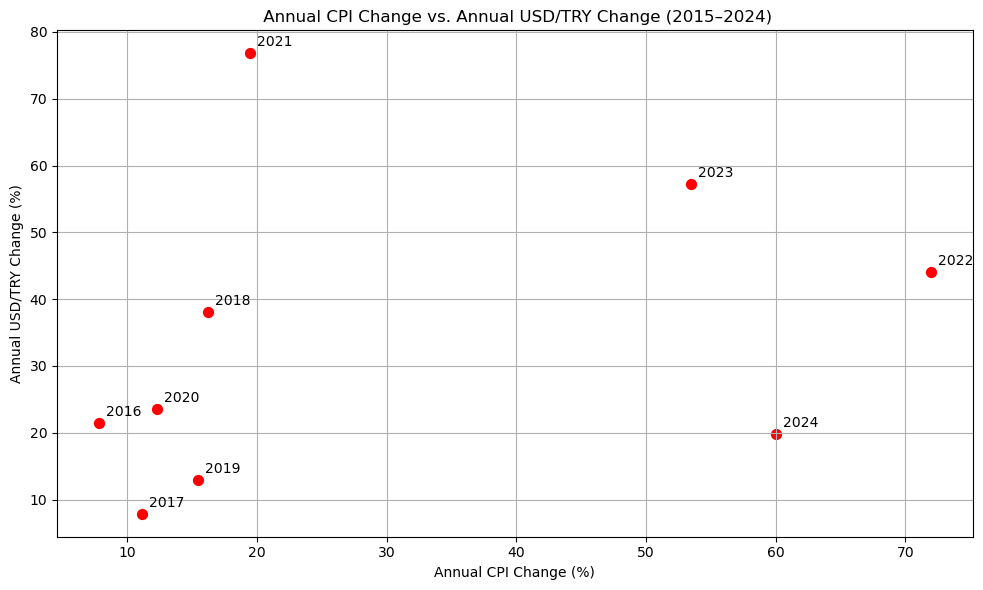

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI

api_key = 'YOUR_EVDS_API_KEY'
cpi_code = 'TP.FG.J0'
usd_try_code = 'TP.DK.USD.S.YTL'
start_date = "01-01-2015"
end_date = "01-01-2025"

evds = evdsAPI(api_key)
df_cpi = evds.get_data([cpi_code], startdate=start_date, enddate=end_date)
df_usd_try = evds.get_data([usd_try_code], startdate=start_date, enddate=end_date)

#Process cpi data
df_cpi['Tarih'] = pd.to_datetime(df_cpi['Tarih'], format='%Y-%m', errors='coerce')
df_cpi.dropna(subset=['Tarih'], inplace=True)
df_cpi.set_index('Tarih', inplace=True)
cpi_col = cpi_code.replace('.', '_')
df_cpi['Annual CPI Change'] = df_cpi[cpi_col].pct_change(12) * 100
df_cpi_annual_change = df_cpi.resample('YE')['Annual CPI Change'].mean().to_frame()
df_cpi_annual_change['Year'] = df_cpi_annual_change.index.year
df_cpi_annual_change.dropna(inplace=True)

#Process Exchange Rate data
df_usd_try['Tarih'] = pd.to_datetime(df_usd_try['Tarih'], dayfirst=True, errors='coerce')
df_usd_try.dropna(subset=['Tarih'], inplace=True)
df_usd_try.set_index('Tarih', inplace=True)
usd_try_yearly = df_usd_try.resample('YE').last()
usd_try_yearly['Previous Year Close'] = usd_try_yearly[usd_try_code.replace('.', '_')].shift(1)
usd_try_yearly['Annual USD/TRY Change'] = ((usd_try_yearly[usd_try_code.replace('.', '_')] - usd_try_yearly['Previous Year Close']) / usd_try_yearly['Previous Year Close']) * 100
usd_try_annual_change = pd.DataFrame(usd_try_yearly['Annual USD/TRY Change'])
usd_try_annual_change['Year'] = usd_try_yearly.index.year
usd_try_annual_change.dropna(subset=['Annual USD/TRY Change'], inplace=True)

#Merging DAta
merged_data = pd.merge(df_cpi_annual_change[['Year', 'Annual CPI Change']], usd_try_annual_change[['Year', 'Annual USD/TRY Change']], on='Year', how='inner')
merged_data.set_index('Year', inplace=True)

# Draw Graph
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['Annual CPI Change'], merged_data['Annual USD/TRY Change'], color='red', marker='o', s=50)
plt.title(' Annual CPI Change vs. Annual USD/TRY Change (2015–2024)')
plt.xlabel('Annual CPI Change (%)')
plt.ylabel('Annual USD/TRY Change (%)')
plt.grid(True)
for year, row in merged_data.iterrows():
    plt.annotate(int(year), (row['Annual CPI Change'], row['Annual USD/TRY Change']), textcoords="offset points", xytext=(5, 5), ha='left')
plt.tight_layout()
plt.show()

**3.2. Inflation and Unemployment**

The traditional Phillips Curve is founded   on the assumption that unemployment and inflation are inverse in relationship. Gulener (2025) stated, however,   that many empirical works that tested   Turkey broke   this classical hypothesis and discovered   a moderate positive relationship between the two variables. This indicates that, as the Turkish economic setting states,   high periods of unemployment were typically succeeded   by a rise in inflation rates   a finding op  posite that which   classical assumptions offer. 

These opposing   results may be triggered by   structural determinants in the Turkish economy, such as labor market rigidities, bottlenecks of supply,   or external disturbances, to   overpower the conventional reverse   relationship. To affirm   this, one specific study found statistically significant positive inflation-unemployment correspondence for the period of 1960 2023   in Turkey. Other studies have,   however, fo  und either no significant interaction or unidirectional causality among variables, displaying immense   variation in the empirical results (Gulener, 2025).

As in   the traditional Phillips Curve, Doğan (2012) indicated   that even in recent work, there remains a positive relationship, and this suggests   that the model is sensible for some degree   under certain economic situations.   These findings reflect the complexity of the inflation-unemployment relationship in Turkey and again signify   the need for additional work   to determine the forces driving and conditions under which different patterns dominate. 

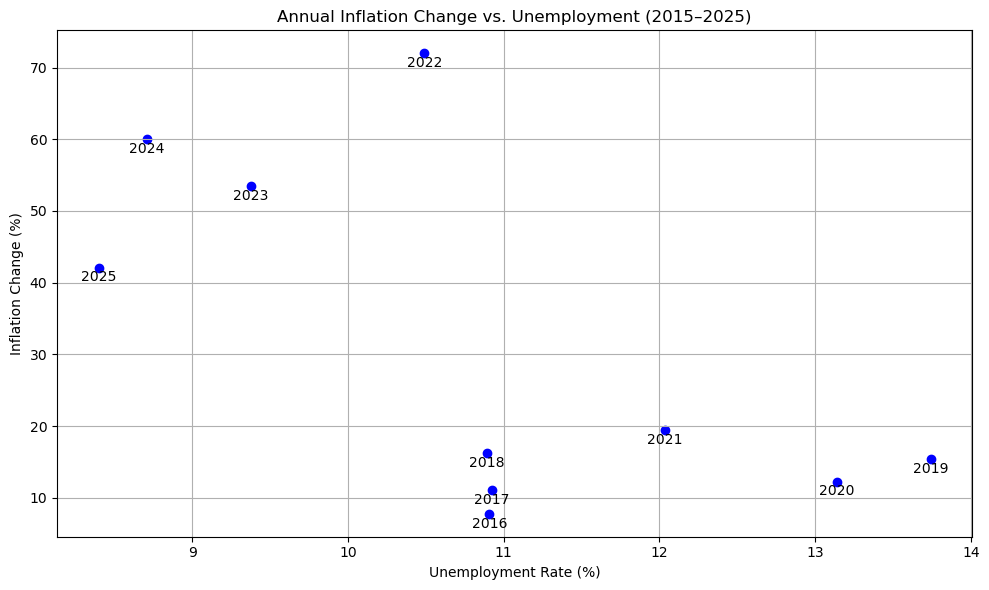

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI

api = evdsAPI('YOUR_EVDS_API_KEY')
codes = {'unemp': 'TP.YISGUCU2.G8', 'infl': 'TP.FG.J0'}
start, end = "01-01-2015", "01-01-2025"

#Get Data
df_unemp = api.get_data([codes['unemp']], startdate=start, enddate=end)
df_infl = api.get_data([codes['infl']], startdate=start, enddate=end)

# Unemployment
df_unemp['Tarih'] = pd.to_datetime(df_unemp['Tarih'], errors='coerce')
df_unemp.set_index('Tarih', inplace=True)
unemp_col = codes['unemp'].replace('.', '_')
df_unemp_y = df_unemp.resample('YE')[unemp_col].mean().rename('Unemployment')

# Inflation
df_infl['Tarih'] = pd.to_datetime(df_infl['Tarih'], errors='coerce')
df_infl.set_index('Tarih', inplace=True)
infl_col = codes['infl'].replace('.', '_')
df_infl['InflationChange'] = df_infl[infl_col].pct_change(12) * 100
df_infl_y = df_infl.resample('YE')['InflationChange'].mean()


df = pd.concat([df_unemp_y, df_infl_y], axis=1).dropna()
df.index = df.index.year
df = df.loc[2015:2025]

# Draw Graph
plt.figure(figsize=(10, 6))
plt.scatter(df['Unemployment'], df['InflationChange'], color='blue')
plt.title('Annual Inflation Change vs. Unemployment (2015–2025)')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Inflation Change (%)')
plt.grid(True)

for year, row in df.iterrows():
    plt.annotate(str(year), (row['Unemployment'], row['InflationChange']), xytext=(0, -10), textcoords='offset points', ha='center')

plt.tight_layout()
plt.show()


**3.3. GDP Per Capita and Unemployment**

The relationship between the unemployment and GDP per capita economic growth in Turkey follows Okun's Law in general. Okun's Law stipulates the inverse correlation between economic growth and unemployment. It formalizes that as the GDP of a country rises above its maximum potential, unemployment declines, ceteris paribus, and conversely, under the assumption of negative correlation between the two indicators. Empirical studies have testified the same, for instance, in the case of Doğans's (2012) study of a negative correlation between unemployment and output in Turkey. That is, periods of high economic growth will be accompanied by low levels of unemployment and vice versa. Garirian, Bilgin and Karabulut (2010) empirical study of some of the MENA countries, including Turkey, also found evidence of a negative long-run relationship between GDP growth and unemployment. This simple macroeconomic relationship informs us that when the Turkish economy is expanding, it will generate more jobs and, therefore, lower unemployment. Assessing whether this correlation held firm through the economic downturns of the pandemic and even in the recovery phases thereafter is vital to identifying the compounding impact of such occurrences on the Turkish labor market.


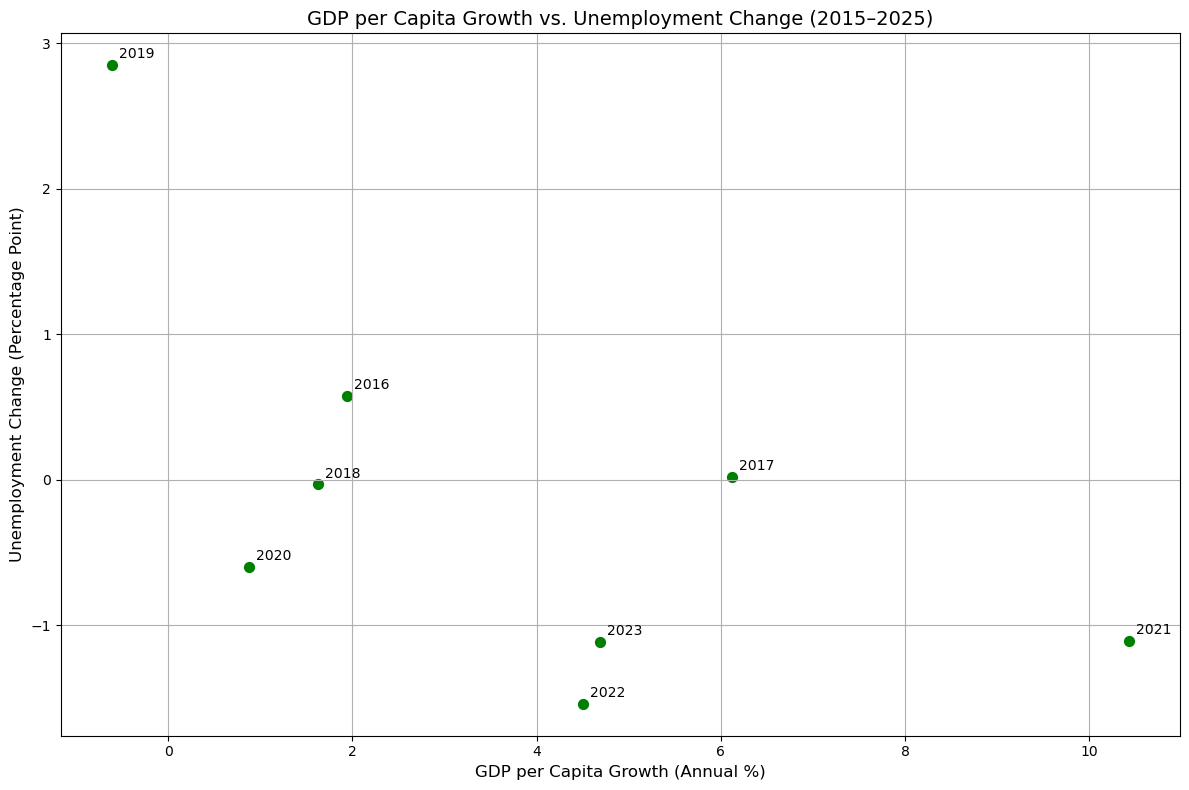

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from evds import evdsAPI

api_key = 'YOUR_EVDS_API_KEY'
unemployment_code = 'TP.YISGUCU2.G8'
start_date = "01-01-2015"
end_date = "01-01-2025"
world_bank_url = "https://api.worldbank.org/v2/country/TUR/indicator/NY.GDP.PCAP.KD.ZG?date=2015:2025&format=json"

evds = evdsAPI(api_key)
df_unemployment = evds.get_data([unemployment_code], startdate=start_date, enddate=end_date)
df_unemployment['Tarih'] = pd.to_datetime(df_unemployment['Tarih'], errors='coerce').dropna()
df_unemployment.set_index('Tarih', inplace=True)
df_unemployment_yillik = df_unemployment.resample('YE').mean()
df_unemployment_yillik['Unemployment Change'] = df_unemployment_yillik[unemployment_code.replace('.', '_')].diff().dropna()
df_unemployment_yillik['Year'] = df_unemployment_yillik.index.year

response = requests.get(world_bank_url)
world_bank_data = response.json()
gdp_data = [{'Year': int(item['date']), 'GDP per Capita Growth': float(item['value'])}
            for item in world_bank_data[1] if item['value'] is not None]
df_gdp_worldbank = pd.DataFrame(gdp_data).set_index('Year')

merged_data = pd.merge(df_gdp_worldbank, df_unemployment_yillik[['Year', 'Unemployment Change']], on='Year').set_index('Year')
merged_data = merged_data[(merged_data.index >= 2015) & (merged_data.index <= 2025)]

plt.figure(figsize=(12, 8))
plt.scatter(merged_data['GDP per Capita Growth'], merged_data['Unemployment Change'], color='green', marker='o', s=50)
plt.title('GDP per Capita Growth vs. Unemployment Change (2015–2025)', fontsize=14)
plt.xlabel('GDP per Capita Growth (Annual %)', fontsize=12)
plt.ylabel('Unemployment Change (Percentage Point)', fontsize=12)
plt.grid(True)
for year, row in merged_data.iterrows():
    plt.annotate(int(year), (row['GDP per Capita Growth'], row['Unemployment Change']), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=10)
plt.tight_layout()
plt.show()

**3.4. GDP Per Capita and Inflation**

The relationship between GDP per capita (economic growth) and inflation in Turkey appears to be positive, particularly in the period of post-pandemic recovery. As Yürük and Akgül (2024) stated, pandemic-era monetary expansions and increased production and energy consumption toward the end of the pandemic fueled inflation by causing costs to rise. World Bank (2022) contended that rapid economic recovery in 2021 crossed with rising inflation. Macroeconomic policies and elevated commodity prices combined to propel this inflationary surge with rapid recuperation from the COVID-19 pandemic. This suggests that robust economic growth after the pandemic could have propelled inflationary pressure, perhaps through rising aggregate demand, supply constraints, or transmission effect of expansionary fiscal and monetary policies implemented to spur the bounce back.

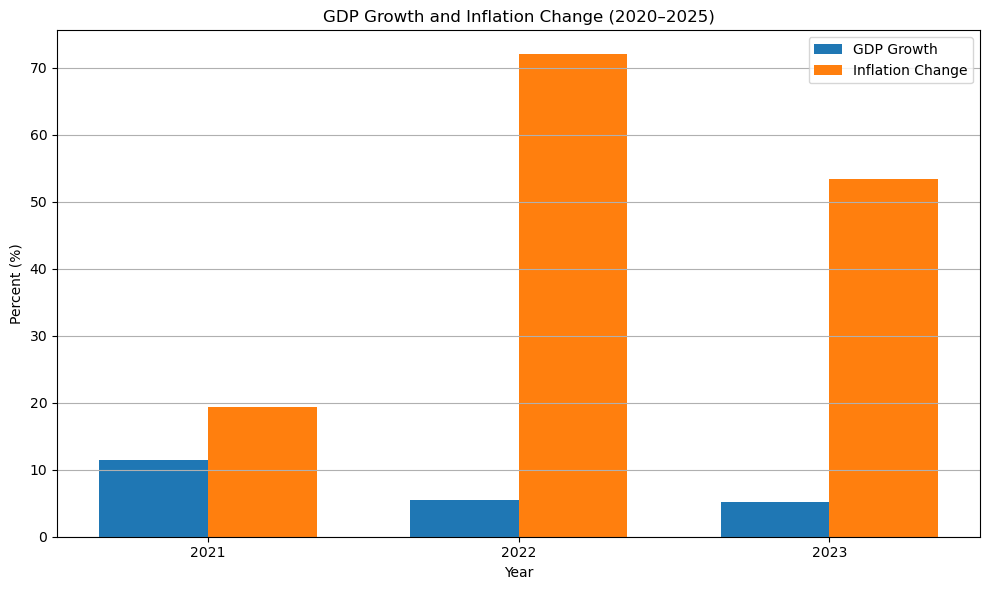

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI
import numpy as np

# Getting 
gdp_row = "Turkiye,\"TUR\",\"GDP growth (annual %)\",\"NY.GDP.MKTP.KD.ZG\",\"\",\"1.1560\",\"5.5714\",\"9.0663\",\"5.4590\",\"2.8235\",\"11.2128\",\"4.7325\",\"6.7780\",\"4.0811\",\"3.2335\",\"5.5667\",\"7.4258\",\"3.2623\",\"5.5945\",\"7.1741\",\"10.4611\",\"3.4066\",\"1.5029\",\"-0.6241\",\"-2.4473\",\"4.8566\",\"3.5632\",\"4.9711\",\"6.7120\",\"4.2413\",\"7.0120\",\"9.4855\",\"2.3207\",\"0.2902\",\"9.2661\",\"0.7202\",\"5.0356\",\"7.6512\",\"-4.6681\",\"7.8782\",\"7.3796\",\"7.5776\",\"2.4041\",\"-3.2631\",\"6.9332\",\"-5.7500\",\"6.4477\",\"5.7632\",\"9.7959\",\"8.9923\",\"6.9480\",\"5.0435\",\"0.8150\",\"-4.8231\",\"8.4271\",\"11.2001\",\"4.7884\",\"8.4858\",\"4.9397\",\"6.0844\",\"3.3230\",\"7.5020\",\"3.0131\",\"0.8185\",\"1.8598\",\"11.4393\",\"5.5334\",\"5.1111\",\"\""
gdp_list = gdp_row.split(',')[5:-1]  # Sayısal değerleri al
gdp_growth = [float(val.replace('"', '')) for val in gdp_list]
years = list(range(1961, 1961 + len(gdp_growth)))

# Selecting year
df_gdp = pd.DataFrame({'Year': years, 'GDP Growth (%)': gdp_growth})
df_gdp = df_gdp[(df_gdp['Year'] >= 2020) & (df_gdp['Year'] <= 2025)]
df_gdp.set_index('Year', inplace=True)

# Getting data from EVDS
api_key = 'YOUR_EVDS_API_KEY'
code = 'TP.FG.J0'
evds = evdsAPI(api_key)
df_inf = evds.get_data([code], startdate="01-01-2020", enddate="01-01-2025")

# Date Converter
df_inf['Tarih'] = pd.to_datetime(df_inf['Tarih'], format='%Y-%m', errors='coerce')
df_inf.set_index('Tarih', inplace=True)
col = code.replace('.', '_')
df_inf['Inflation Change (%)'] = df_inf[col].pct_change(12) * 100

df_inf_yearly = df_inf.resample('YE')['Inflation Change (%)'].mean().dropna()
df_inf_yearly.index = df_inf_yearly.index.year
df_inf_yearly = df_inf_yearly.to_frame()

# Merging datass
df_merged = pd.merge(df_gdp, df_inf_yearly, left_index=True, right_index=True)

# Draw Graph
x = np.arange(len(df_merged))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, df_merged['GDP Growth (%)'], width, label='GDP Growth')
ax.bar(x + width/2, df_merged['Inflation Change (%)'], width, label='Inflation Change')

ax.set_ylabel('Percent (%)')
ax.set_xlabel('Year')
ax.set_title('GDP Growth and Inflation Change (2020–2025)')
ax.set_xticks(x)
ax.set_xticklabels(df_merged.index)
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()


**3.5. USD/TRY Exchange Rate and Unemployment**

The relationship of unemployment with the USD/TRY exchange rate in Turkey is highly sophisticated and complicated. Akarsu (2022) discovered that exchange rate volatility has been shown to increase unemployment at a considerable extent. According to Yılmazkuday (2022), positive shocks of the exchange rate have been known to increase unemployment in initial phases. Ahmed, Hasan and Uddin (2022) discovered that currency appreciation, however, would be harmful to employment through raising domestic goods prices to foreign consumers. Some research such as Güler et. al. documented high correlation between exchange rates and unemployment in Turkey. Akarsu (2022) reported that depreciation of Lira can increase unemployment in the form of higher price of imported intermediate and capital goods, especially in the cases where inputs and labor are substitutable. Furthermore, higher wages with depreciation-based expected price inflation are also detrimental to employment. Once more, as proposed by Akarsu (2022), a depreciation can improve employment through higher exports based on higher competitiveness in the foreign market. The net effect of exchange rate movements on Turkish unemployment will depend on the interaction of the various factors and can differ in different economic cycles as well as within the framework of specific shocks.

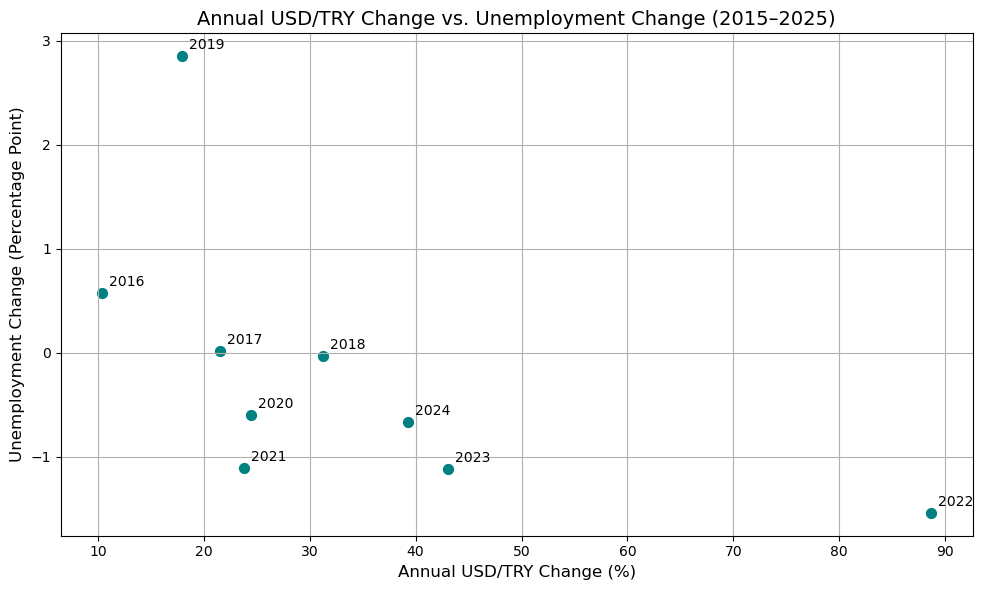

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI

api_key = 'YOUR_EVDS_API_KEY'
usd_try_code = 'TP.DK.USD.A.YTL'
unemployment_code = 'TP.YISGUCU2.G8'
start_date = "01-01-2015"
end_date = "01-01-2025"

evds = evdsAPI(api_key)

# USD/TRY Data
df_usd_try = evds.get_data([usd_try_code], startdate=start_date, enddate=end_date)
df_usd_try['Tarih'] = pd.to_datetime(df_usd_try['Tarih'], errors='coerce').dropna()
df_usd_try.set_index('Tarih', inplace=True)
df_usd_try_yillik = df_usd_try.resample('YE').mean()
df_usd_try_yillik['Annual USD/TRY Change (%)'] = df_usd_try_yillik[usd_try_code.replace('.', '_')].pct_change(fill_method=None) * 100
df_usd_try_yillik.dropna(subset=['Annual USD/TRY Change (%)'], inplace=True)
df_usd_try_yillik['Year'] = df_usd_try_yillik.index.year

# Unemployment Data
df_unemployment = evds.get_data([unemployment_code], startdate=start_date, enddate=end_date)
df_unemployment['Tarih'] = pd.to_datetime(df_unemployment['Tarih'], errors='coerce').dropna()
df_unemployment.set_index('Tarih', inplace=True)
df_unemployment_yillik = df_unemployment.resample('YE').mean()
df_unemployment_yillik['Unemployment Change (Percentage Point)'] = df_unemployment_yillik[unemployment_code.replace('.', '_')].diff()
df_unemployment_yillik.dropna(subset=['Unemployment Change (Percentage Point)'], inplace=True)
df_unemployment_yillik['Year'] = df_unemployment_yillik.index.year

# Merging Data
merged_data = pd.merge(df_usd_try_yillik[['Year', 'Annual USD/TRY Change (%)']], df_unemployment_yillik[['Year', 'Unemployment Change (Percentage Point)']], on='Year').set_index('Year')
merged_data = merged_data[(merged_data.index >= 2015) & (merged_data.index <= 2025)]

# Draw Graph
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['Annual USD/TRY Change (%)'], merged_data['Unemployment Change (Percentage Point)'], color='teal', marker='o', s=50)
plt.title('Annual USD/TRY Change vs. Unemployment Change (2015–2025)', fontsize=14)
plt.xlabel('Annual USD/TRY Change (%)', fontsize=12)
plt.ylabel('Unemployment Change (Percentage Point)', fontsize=12)
plt.grid(True)
for year, row in merged_data.iterrows():
    plt.annotate(int(year), (row['Annual USD/TRY Change (%)'], row['Unemployment Change (Percentage Point)']), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=10)
plt.tight_layout()
plt.show()

**3.6. USD/TRY Exchange Rate and GDP Per Capita**

USD/TRY exchange rate significantly influences the GDP per capita of Turkey. According to Hasan, Ahmed and Uddin (2022) exchange rate fluctuations can result in a change in national income. Akalper (2025) claimed that While depreciation of the Lira would theoretically boost exports, and thus GDP, Turkey's reliance on imported intermediate goods means that a sudden or continued depreciation could harm costs of production and suppress economic growth. Exchange rate volatility also results in uncertainty, which will discourage both domestic and foreign investment, hence affecting long-term GDP growth. Erdoğdu (2017) underlined that the actual exchange rate has also been understood as a critical determinant of household saving in Turkey, and household saving is a primary determinant of economic growth. Therefore, the stability and value of the USD/TRY exchange rate are critical determinants of the general economic performance and GDP per capita of Turkey.

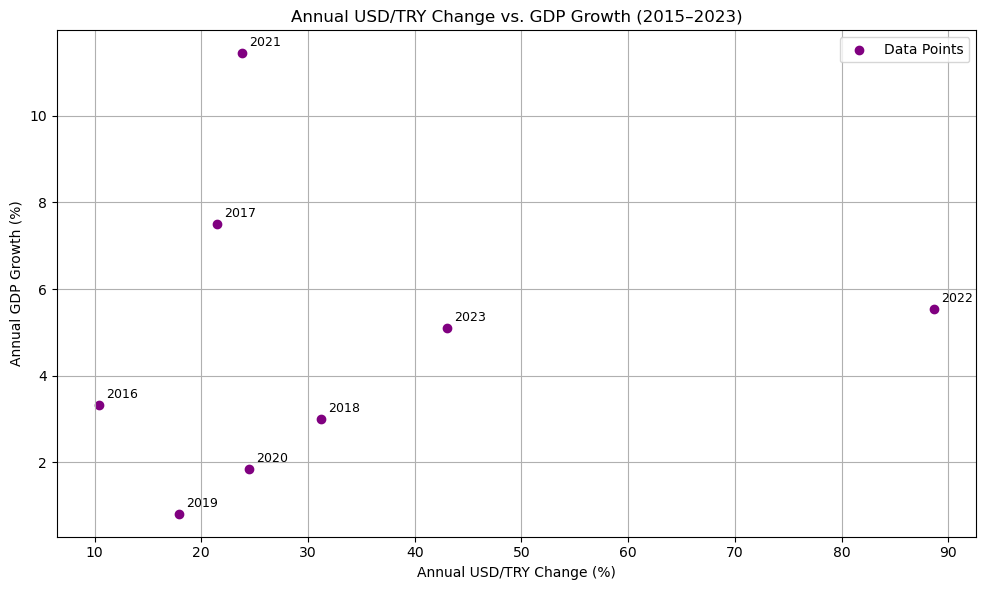

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from evds import evdsAPI

# Getting data from World Bank
gdp_data_row = "Turkiye,\"TUR\",\"GDP growth (annual %)\",\"NY.GDP.MKTP.KD.ZG\",\"\",\"1.15606938539699\",\"5.57142858180484\",\"9.06630555240875\",\"5.45905679838097\",\"2.82352954343837\",\"11.2128150353514\",\"4.73251024393741\",\"6.77799601038116\",\"4.0811456208947\",\"3.2335089729326\",\"5.56669450058789\",\"7.42578832564243\",\"3.26233451840511\",\"5.59447440269336\",\"7.17411268977106\",\"10.4611795563238\",\"3.40666980449156\",\"1.50293301122329\",\"-0.624113570222889\",\"-2.44735042580156\",\"4.85664876652039\",\"3.56322781218346\",\"4.97108077727097\",\"6.71201571206008\",\"4.24133571639945\",\"7.01203111054399\",\"9.48553884246731\",\"2.3207367939484\",\"0.2902440687796\",\"9.26614667149323\",\"0.720279035610048\",\"5.03563493896803\",\"7.65126520301509\",\"-4.66814736394838\",\"7.87826687618991\",\"7.37966447375686\",\"7.57766364407608\",\"2.40415025686937\",\"-3.26316840597104\",\"6.93323970455904\",\"-5.75000655464257\",\"6.44772204681594\",\"5.76320606654714\",\"9.79593638920282\",\"8.99230493626517\",\"6.94798808571993\",\"5.04350793157104\",\"0.815024573007705\",\"-4.82315395301769\",\"8.42710432276191\",\"11.2001105833504\",\"4.78849271108008\",\"8.48581699653026\",\"4.9397151613658\",\"6.08448690443663\",\"3.32308420845746\",\"7.50199748917491\",\"3.0131703931215\",\"0.818514526726673\",\"1.85987303976462\",\"11.4393956926566\",\"5.53342787492781\",\"5.11116818488702\",\"\""
gdp_data_list = gdp_data_row.split(',')
gdp_growth_rates = [float(rate.replace('"', '')) for rate in gdp_data_list[5:-1]]
start_year_gdp = 1961
years_gdp = list(range(start_year_gdp, start_year_gdp + len(gdp_growth_rates)))
df_gdp = pd.DataFrame({'Year': years_gdp, 'Annual GDP Growth (%)': gdp_growth_rates}).set_index('Year')
df_gdp_filtered = df_gdp[(df_gdp.index >= 2015) & (df_gdp.index <= 2025)]

#Getting data form EVDS
api_key = 'YOUR_EVDS_API_KEY'
usd_try_code = 'TP.DK.USD.A.YTL'
start_date_evds = "01-01-2015"
end_date_evds = "01-01-2025"
evds = evdsAPI(api_key)
df_usd_try = evds.get_data([usd_try_code], startdate=start_date_evds, enddate=end_date_evds)
df_usd_try['Tarih'] = pd.to_datetime(df_usd_try['Tarih'], errors='coerce').dropna()
df_usd_try.set_index('Tarih', inplace=True)
df_usd_try_yillik = df_usd_try.resample('YE').mean()
df_usd_try_yillik['Annual USD/TRY Change (%)'] = df_usd_try_yillik[usd_try_code.replace('.', '_')].pct_change(fill_method=None) * 100
df_usd_try_yillik.dropna(subset=['Annual USD/TRY Change (%)'], inplace=True)
df_usd_try_yillik['Year'] = df_usd_try_yillik.index.year
df_usd_try_yillik_filtered = df_usd_try_yillik[(df_usd_try_yillik['Year'] >= 2015) & (df_usd_try_yillik['Year'] <= 2025)]

# Merging the data
merged_data = pd.merge(df_usd_try_yillik_filtered[['Year', 'Annual USD/TRY Change (%)']], df_gdp_filtered[['Annual GDP Growth (%)']], on='Year').set_index('Year')

# Drawing the graph
plt.figure(figsize=(10, 6))
plt.scatter(merged_data['Annual USD/TRY Change (%)'], merged_data['Annual GDP Growth (%)'], color='purple', label='Data Points')
plt.title('Annual USD/TRY Change vs. GDP Growth (2015–2023)')
plt.xlabel('Annual USD/TRY Change (%)')
plt.ylabel('Annual GDP Growth (%)')
plt.grid(True)
for year, row in merged_data.iterrows():
    plt.annotate(int(year), (row['Annual USD/TRY Change (%)'], row['Annual GDP Growth (%)']), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

**4. Impact of COVID-19 on Macroeconomic Correlations**

The COVID-19 pandemic, with its special traits and the never-before-seen policy reactions put in place around the globe and in Turkey, probably had a notable effect on the prior links between the main macroeconomic indicators. In the opinion of Voyvoda and Yeldan (2021), the connection between GDP also joblessness, which commonly tracks Okun's Law may have been changed by government help plans meant to hold onto jobs during closures and money upsets. Those actions could have briefly made the clear backward link between a drop in the economy and joblessness that goes up less firm. Çakmaklı et al. (2021) said that also, the firm forward link between the USD/TRY exchange number and rising prices may have been made bigger by the increased worldwide doubt that was around during the health crisis, upsets to supply lines that cross borders as well as the forceful money loosening taken up by Turkey when facing the crisis. A health crisis also worsened the weak spots already there in the Turkish economy, perhaps causing a more obvious exchange number moving into rising prices than the time before COVID. The quick return of the economy that was spotted in 2021, as a plus for GDP increase, came at the same time as a rush in rising prices, showing that the connection between those two indicators may have become firmer or changed during the time after the health crisis. The special type of hit the COVID-19 caused, touching both supply besides demand at the same time, with the size of policy actions taken, built a setting where time-honored macroeconomic links could have been changed a lot.

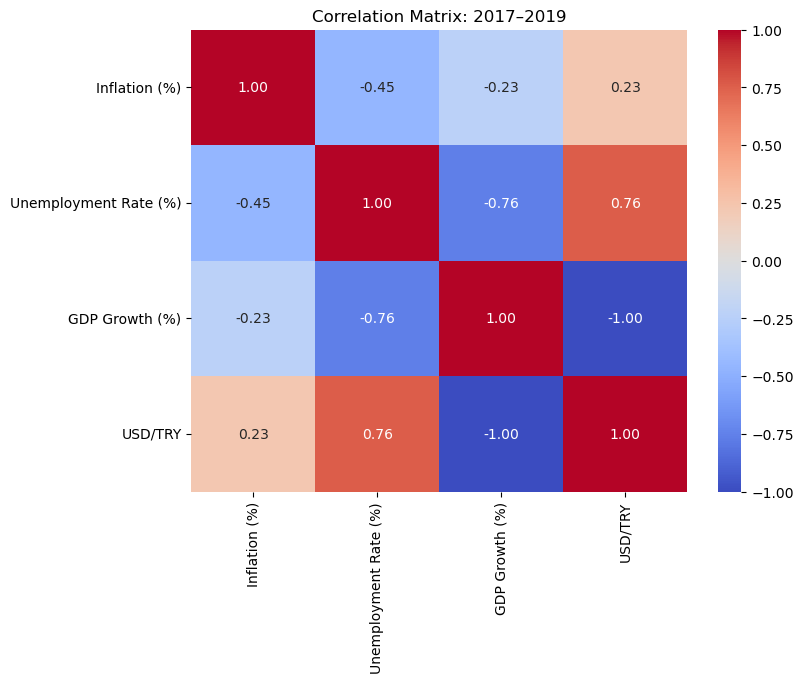

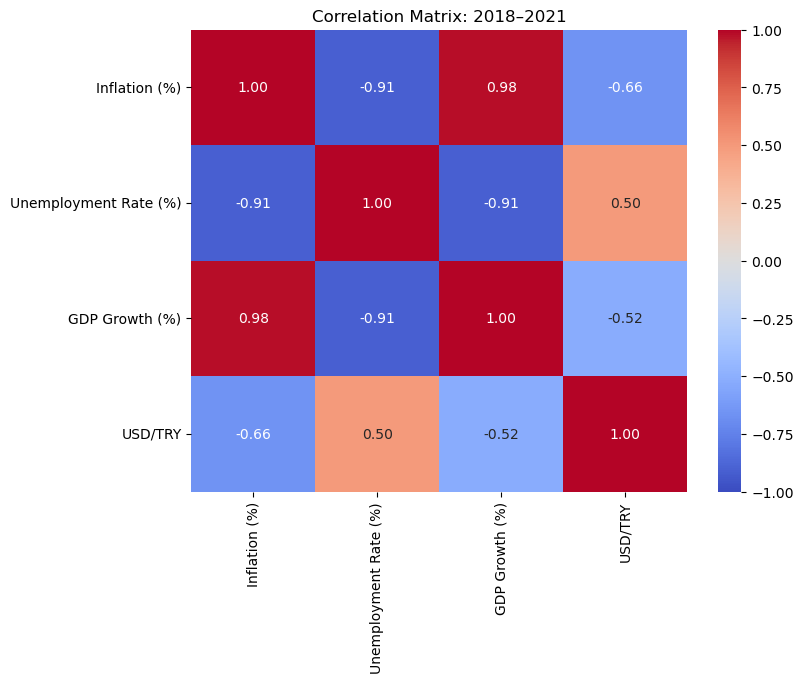

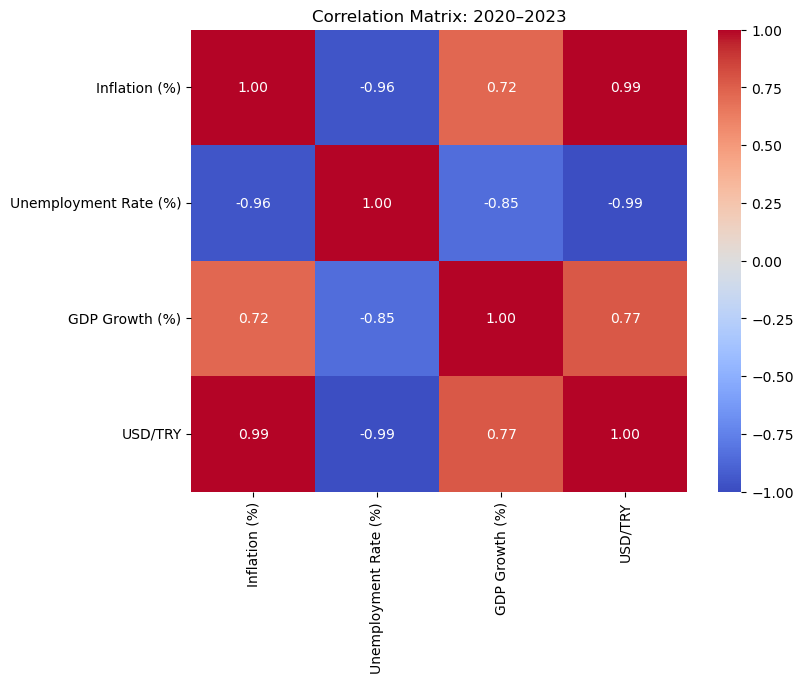

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Period 1: 2017–2019
data_1 = pd.DataFrame({
    "Date": pd.date_range("2017-01-01", "2019-01-01", freq="YS"),
    "Inflation (%)": [11.9, 20.3, 11.8],
    "Unemployment Rate (%)": [10.8, 11.0, 13.7],
    "GDP Growth (%)": [7.5, 2.8, 0.9],
    "USD/TRY": [3.65, 5.30, 5.95]
}).set_index("Date")

# Period 2: 2018–2021
data_2 = pd.DataFrame({
    "Date": pd.date_range("2018-01-01", "2021-01-01", freq="YS"),
    "Inflation (%)": [20.3, 11.8, 14.6, 12.3],
    "Unemployment Rate (%)": [11.0, 13.7, 13.2, 12.7],
    "GDP Growth (%)": [2.8, 0.9, 1.8, 1.3],
    "USD/TRY": [5.30, 5.95, 6.90, 7.43]
}).set_index("Date")

# Period 3: 2020–2023
data_3 = pd.DataFrame({
    "Date": pd.date_range("2020-01-01", "2023-01-01", freq="YS"),
    "Inflation (%)": [14.6, 12.3, 36.1, 64.3],
    "Unemployment Rate (%)": [13.2, 12.7, 10.5, 9.4],
    "GDP Growth (%)": [1.8, 1.3, 5.6, 4.3],
    "USD/TRY": [6.90, 7.43, 13.30, 18.70]
}).set_index("Date")

# Function to draw graph
def plot_corr_matrix(data, title):
    corr = data.corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title(title)
    plt.show()

# Plot correlation matrices
plot_corr_matrix(data_1, "Correlation Matrix: 2017–2019")
plot_corr_matrix(data_2, "Correlation Matrix: 2018–2021")
plot_corr_matrix(data_3, "Correlation Matrix: 2020–2023")


**Correlation Matrix**

These 3 different matrices show us  how inflation , unemployment , USD/TRY Exchange rate and GDP growth affect the Turkish economy. There are 3 period in this research pre covid , during covid and past covid, these matrices are helping to understand how relation between these variables changes across periods.

Firstly, pre covid(2017-2019)
in this period correlations are proportianally weak for other periods. For instance, the correlation between inflation and gdp growth is -0,23. In contraast to this, the correlation between USD/TRY Echange rate and GDP Growth is stronger. Additionally the correlation between unemployment and GDP Growth is strong and negative, also this situation supports the Okun's law.

Start of the covid effect(2018-2019)
In this period, after the effects of covid started, correlations became more stronger. For instance, the correlation between inflation and GDP Growth almost became totally positive correlation(0,98).In this period relation between inflation and unemployment is more significant. additionally, the relation between inflation and USD/TRY is became weak negative(-0.66).

Post covid(2020-2023)
In this period, correlations became more stronger than first 2 periods. For insatnce, the correlation between inflation and USD/TRY (0.99) show us how this relationship became more and more stronger. Also, correlation between unemployment and USD/TRY became significantly stronger and this situation may show us exports increase the employment. In addition to these, correlation between inflation and unemployment became proportionally stronger(-0.85) and shows us The Okun's law still working


**CONCLUSİON**

The research has methodically analyzed the changing macroeconomic relations among inflation, the exchange rate of USD/TRY, GDP per capita, and unemployment in Turkiye, especially for the times pre covid, during covid and past  covid 19 pandemic. The comparison of three correlation matrices testifies to the fact that not only have these interdependencies strengthened with the passage of time but also have structurally become more polarized, especially following the worldwide health crisis. While in the pre pandemic period there were quite unsystematic and imperfect correlations, the pandemic and post-pandemic periods have witnessed the creation of exceptionally high and, in some cases, counterintuitive correlations between primary indicators. The almost perfect positive association between the exchange rate and inflation testifies to the extent to which Turkey's price stability has become susceptible to currency volatility, assuming a robust exchange rate pass-through effect fueled by monetary expansion at home and risks abroad. Meanwhile, the long run   adverse correlation of GDP per capita and unemployment confirms the applicability of Okun's Law to the Turkish case, with output contraction still commanding high job costs. Nevertheless, the noted negative relationship between unemployment and inflation post COVID   indicates a failure of the conventional Phillips Curve theory, possibly an indication of short run   demand pulls, distortions in the labor market, and cost push   inflationary tensions instead of real improvements in employment generation. Taken cumulatively, these findings suggest that Turkey's macroeconomic environment is increasingly integrated and vulnerable to shock, where a shift in one variable can instantly cause ripple effects across the entire economic structure. Therefore, designing a proper policy response entails more than siloing individual indicators, it requires an overarching and active approach that stabilizes the currency, enhances investor confidence, and generates inclusive growth that is productivity oriented.   Unless these interconnected dynamics are identified and dealt with, they would contribute to a worsening of structural imbalances,  uncertainty, and lessened economic resilience in the face of future shocks.

**Referrence list**


Baez, J. E., & Demirgüç-Kunt, A. (2021). The urgency of promoting a more equal recovery: Insights from the COVID-19 crisis in Turkey. World Bank Blogs. Retrieved May 14, 2025, from https://blogs.worldbank.org/europeandcentralasia/urgency-promoting-more-equal-recovery-insights-covid-19-crisis-turkey

Doğan, T. T. (2012). Macroeconomic variables and unemployment: The case of Turkey. International Journal of Economics and Financial Issues, 2(1), 71–78. İlhan Öztürk.

Gulener, K. (2024). The relationship between unemployment and inflation: A Turkish economy perspective. Retrieved from https://mpra.ub.uni-muenchen.de/121932/

Güler, M., Kabakçı, A., Koç, Ö., Eraslan, E., Derin, K. H., Güler, M., Ünlü, R., Türkan, Y. S., & Namlı, E. (2024). Forecasting of the Unemployment Rate in Turkey: Comparison of the Machine Learning Models. Sustainability, 16(15), 6509. https://doi.org/10.3390/su16156509

Haririan, M., Bilgin, M. H., & Karabıyık, L. (2010). The relationship between GDP and unemployment: Evidence from Turkey. Zagreb International Review of Economics & Business, 13(1), 17–28. Sveučilište u Zagrebu Ekonomski fakultet.

Turkey Economic Monitor: Sailing against the tide. (n.d.). World Bank. Retrieved May 14, 2025, from https://www.worldbank.org/en/country/turkey/publication/economic-monitor

Uddin, M. S., Ahmed, Z., & Hasan, M. (2022). The relationship between the exchange rate, trade terms and employment in Turkey. Apuntes del CENES, 41(74), 177–200. https://doi.org/10.19053/01203053.v41.n74.2022.14251

Voyvoda, E., & Yeldan, A. E. (2020). A general equilibrium analysis of the impact of the COVID-19 pandemic on the Turkish economy. 

Voyvoda, E., & Yeldan, A. E. (2020). Impact of the COVID-19 outbreak on Turkey’s economy and a policy alternative for protecting labor incomes. Political Economy Research Institute.

Wilson, M. M., & Taborsky, J. F. (n.d.). Monitoring Turkey: Stronger fiscal policies will help the disinflation process. ING Think. Retrieved May 14, 2025, from https://think.ing.com/articles/turkey-stronger-fiscal-policies-will-help-the-disinflation-process/

Yürük, B., & Akgül, A. (2024). Determinants of inflation in Turkey amid economic shocks. Yönetim ve Ekonomi Araştırmaları Dergisi, 22(3), 221–238. Bandırma Onyedi Eylül University.